## Lecture 8 - (05/03/2026)

Today's Topics:

- Networkx


In [2]:
import networkx as nx

A Network Graph displays relationships between entities and can be used to identify correlations or flows between items. 

The Network graph supports a two-level breakdown defining the "From", and "To", where each node (vertex / point), is either in the "From", or "To" levels of the breakdown, and each edge (or line), represents the data specific to this "From and To" relationship.

The size of the node is specific to the number of interactions / relationships it has with other nodes.  There can be up to two lines connecting two nodes, which can display arrows to show direction; and represent the "From and To" combinations.

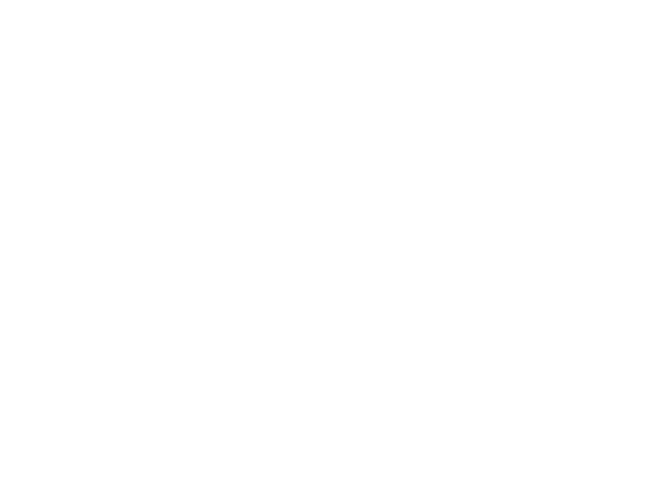

In [24]:
G = nx.Graph()

nx.draw(G)

### Nodes

The graph $G$ can be grown in several ways. NetworkX includes many graph generator functions and facilities to read and write graphs in many formats. To get started though we’ll look at simple manipulations. You can add one node at a time:

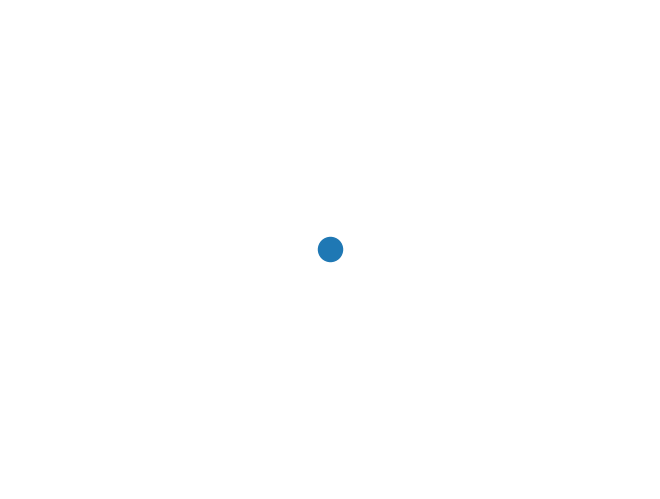

In [25]:
G.add_node(1)
nx.draw(G)

or we can add nodes from any iterable container, such as a list:

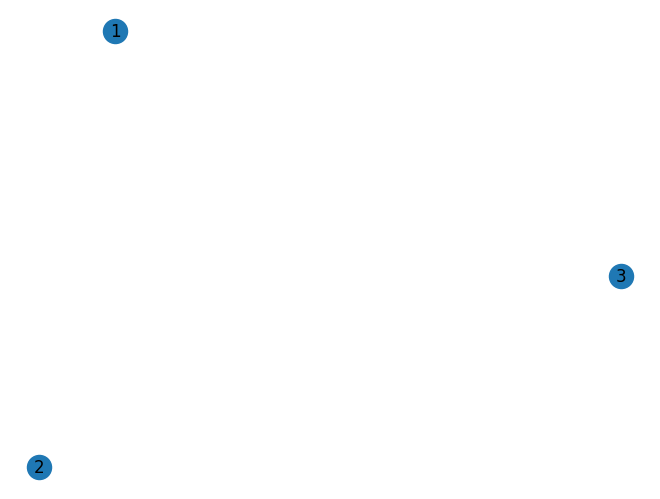

In [26]:
G.add_nodes_from([2,3])
nx.draw(G, with_labels=True)

You can also add nodes along with node attributes if your container yields 2-tuples of the form `(node, node_attribute_dict)`:


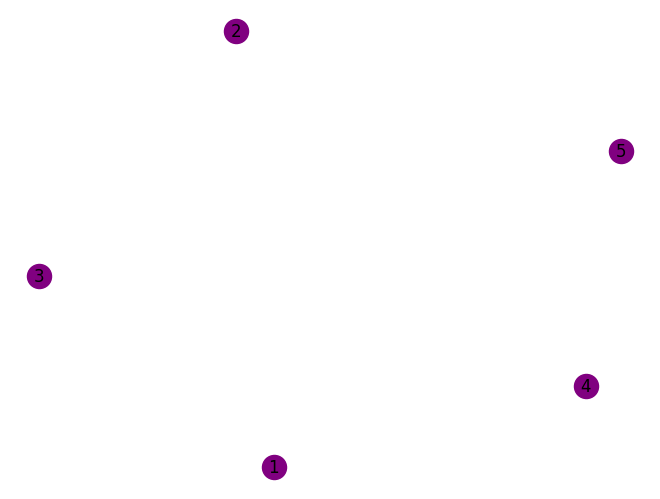

In [18]:
G.add_nodes_from([
    (4, {'color': 'red'}),
    (5, {'color': 'green'})
])

nx.draw(G, with_labels=True, node_color='purple')

Here let's use the `path_graph` function to generate linearly connected nodes

In [ ]:
H = nx.path_graph(10)
nx.draw(H)

In [32]:
G.add_nodes_from(H)

G now contains the nodes of H as nodes of G. In contrast, you could use the graph H as a node in G.

In [33]:
G.add_node(H)

The graph `G` now contains `H` as a node. This flexibility is very powerful as it allows graphs of graphs, graphs of files, graphs of functions and much more. It is worth thinking about how to structure your application so that the nodes are useful entities. Of course you can always use a unique identifier in `G` and have a separate dictionary keyed by identifier to the node information if you prefer.

### Edges

`G` can also be grown by adding one edge at a time,

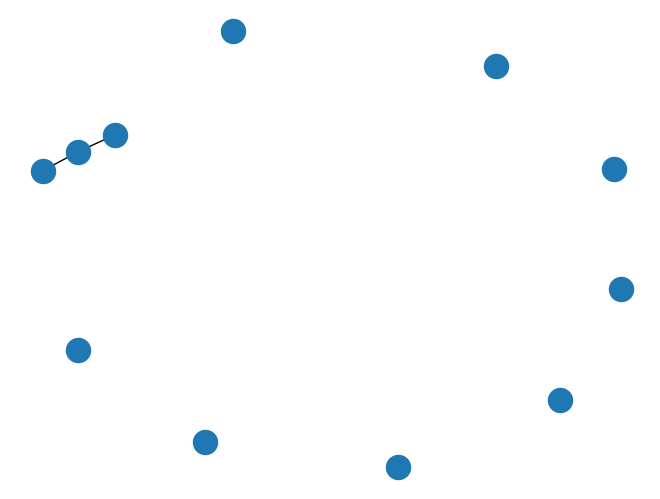

In [35]:
G.add_edge(1, 2)
e = (2, 3)
G.add_edge(*e)

nx.draw(G)

by adding a list of edges,

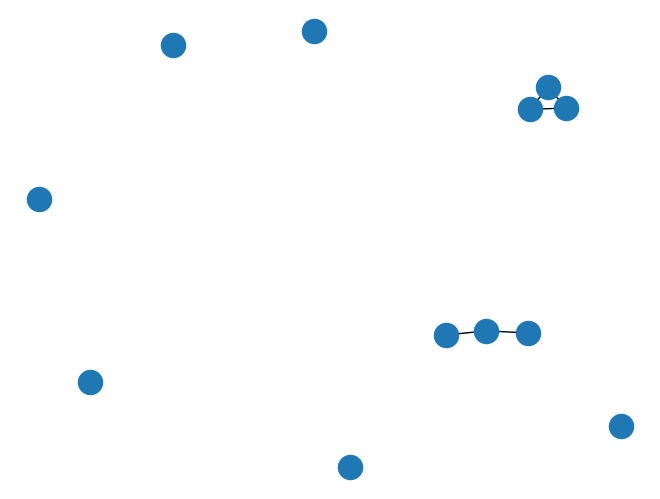

In [37]:
G.add_edges_from([(8, 10), (9, 10), (8,9)])
nx.draw(G)

or by adding any ebunch of edges. An ebunch is any iterable container of edge-tuples. An edge-tuple can be a 2-tuple of nodes or a 3-tuple with 2 nodes followed by an edge attribute dictionary, e.g., `(2, 3, {'weight': 3.1415}`). Edge attributes are discussed further below.

In [38]:
G.add_edges_from(H.edges)

In [39]:
G.clear()

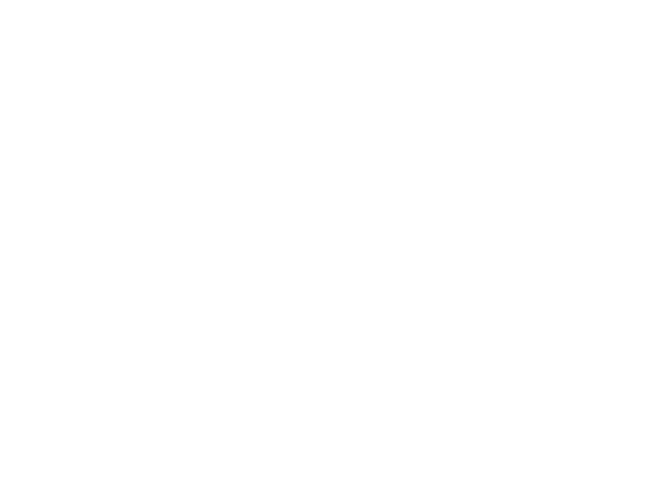

In [40]:
nx.draw(G)

we add new nodes/edges and NetworkX quietly ignores any that are already present.

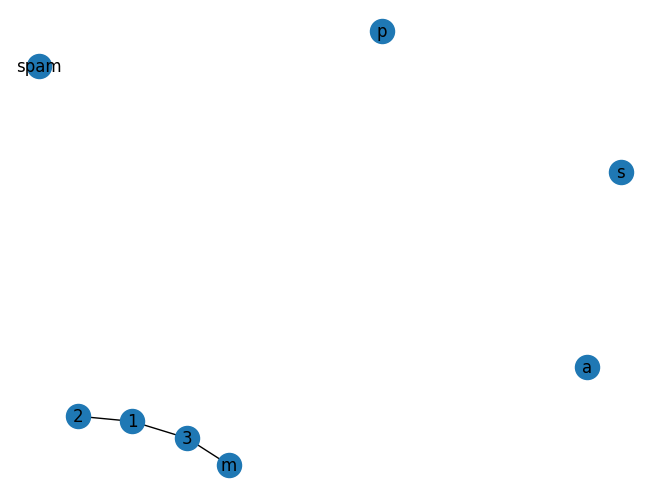

In [41]:
G.add_edges_from([(1, 2), (1, 3)])
G.add_node(1)
G.add_edge(1, 2)
G.add_node("spam")       # adds nodes 'spam'
G.add_nodes_from("spam") # adds nodes 's', 'p', 'a', 'm'
G.add_edge(3, 'm')       # connects node 'm' to '3' 

nx.draw(G, with_labels=True)

At this stage the graph `G` consists of 8 nodes and 3 edges, as can be seen by:

In [42]:
print(G.number_of_nodes())
print(G.number_of_edges())

8
3


### Digraphs

In [43]:
DG = nx.DiGraph()
DG.add_edge(2, 1)   # adds the nodes in order 2, 1
DG.add_edge(1, 3)
DG.add_edge(2, 4)
DG.add_edge(1, 2)
print(list(DG.successors(2))) # generate list of all sucessor of 2 in the graph

[1, 4]


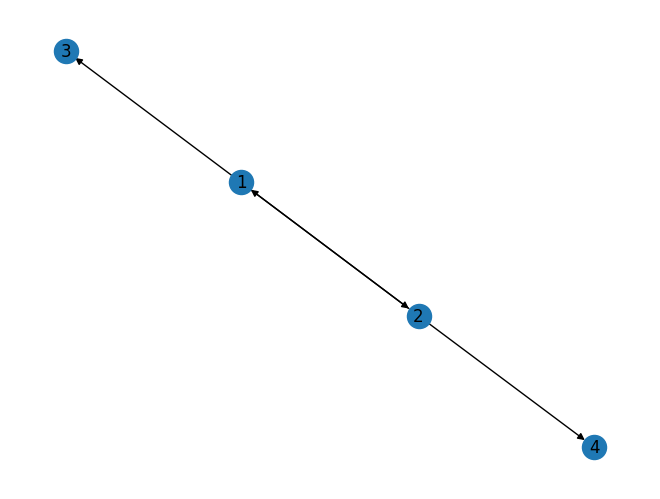

In [44]:
nx.draw(DG, with_labels=True)

We can examine the nodes and edges. Four basic graph properties facilitate reporting: `G.nodes`, `G.edges`, `G.adj` and `G.degree`. These are set-like views of the nodes, edges, neighbors (adjacencies), and degrees of nodes in a graph. They offer a continually updated read-only view into the graph structure. They are also dict-like in that you can look up node and edge data attributes via the views and iterate with data attributes using methods `.items()`, `.data()`. If you want a specific container type instead of a view, you can specify one. Here we use lists, though sets, dicts, tuples and other containers may be better in other contexts.

In [45]:
print("Node List",list(G.nodes))
print("Edge List",list(G.edges))
print("G.neighbors",list(G.adj[1]))  # or list(G.neighbors(1))
print("Degree of node (1)",G.degree[1])  # the number of edges incident to 1

Node List [1, 2, 3, 'spam', 's', 'p', 'a', 'm']
Edge List [(1, 2), (1, 3), (3, 'm')]
G.neighbors [2, 3]
Degree of node (1) 2


One can specify to report the edges and degree from a subset of all nodes using an nbunch. An nbunch is any of: None (meaning all nodes), a node, or an iterable container of nodes that is not itself a node in the graph.

In [46]:
print(G.edges([2, 'm']))
print(G.degree([2, 3]))

[(2, 1), ('m', 3)]
[(2, 1), (3, 2)]


One can remove nodes and edges from the graph in a similar way to adding. Use methods `Graph.remove_node()`, `Graph.remove_nodes_from()`, `Graph.remove_edge()` and `Graph.remove_edges_from()`, e.x.

[1, 2, 3, 'spam', 's', 'p', 'a', 'm']
[(1, 2), (1, 3), (3, 'm')]


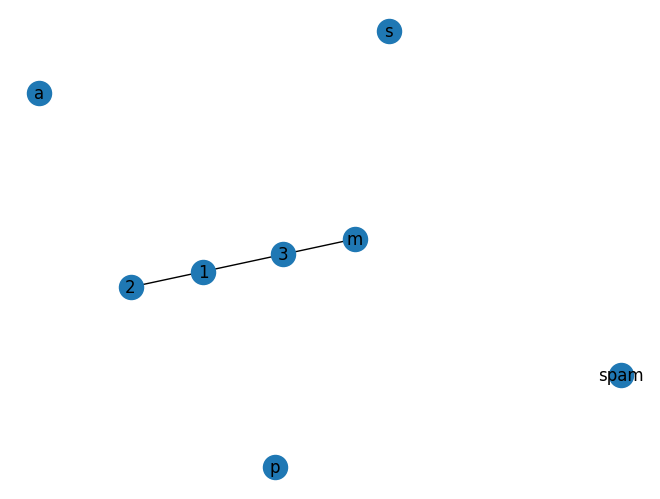

In [47]:
# before removal

print(G.nodes)
print(G.edges)
nx.draw(G,with_labels=True)

In [48]:
G.remove_node(2)
G.remove_nodes_from("spam")
G.remove_edge(1, 3)

[1, 3, 'spam']
[]


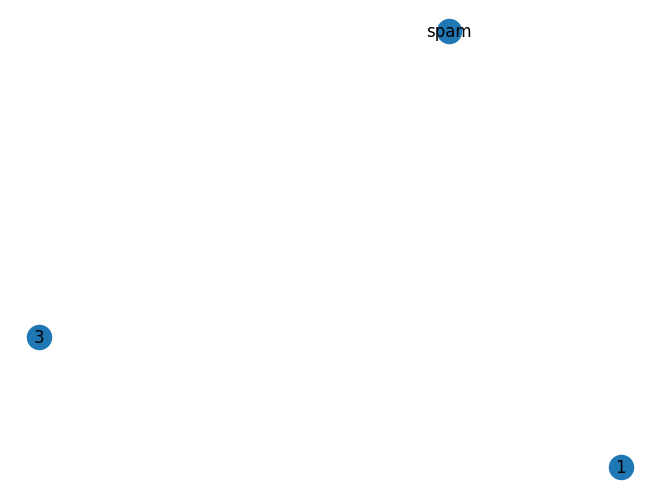

In [49]:
# after removal

print(G.nodes)
print(G.edges)
nx.draw(G,with_labels=True)

Graph objects do not have to be built up incrementally - data specifying graph structure can be passed directly to the constructors of the various graph classes. When creating a graph structure by instantiating one of the graph classes you can specify data in several formats.

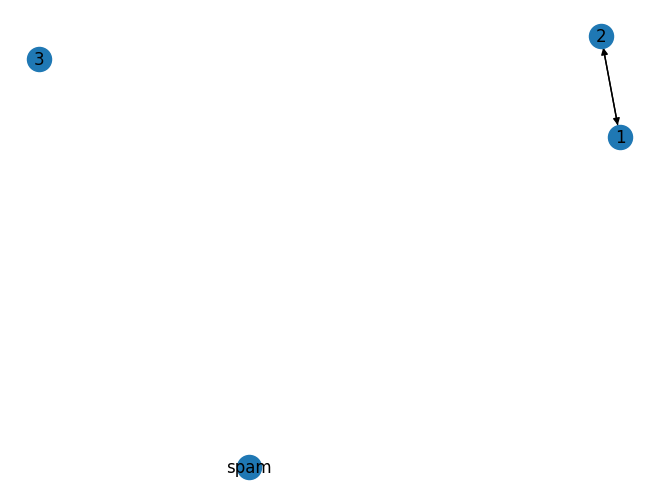

In [50]:
G.add_edge(1, 2)
H = nx.DiGraph(G)  # create a DiGraph using the connections from G

nx.draw(H, with_labels=True)

In [52]:
print(H.edges())
print(H.nodes())

[(1, 2), (2, 1)]
[1, 3, 'spam', 2]


In [ ]:
edges = [(1,2), (2,1)]
nodes = [1,3,'spam',2]

adj_dict = {}

for key in nodes:
    adj_dict[key] = []
    for val, item in edges:
        if val == key:
            adj_dict[key].append(item)

print(adj_dict)

{1: [2], 3: [], 'spam': [], 2: [1]}


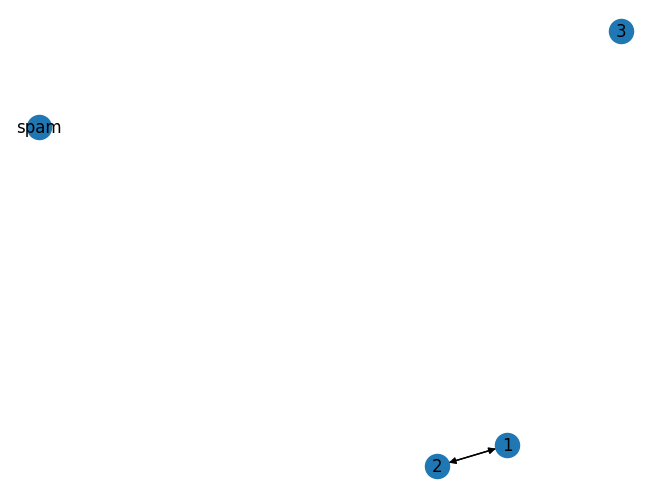

In [59]:
H = nx.DiGraph(adj_dict)
nx.draw(H, with_labels=True)

### Accessing edges and neighbours

In addition to the views `Graph.edges`, and `Graph.adj`, access to edges and neighbors is possible using subscript notation.

{2: {'color': 'yellow'}}
{'color': 'yellow'}
{'color': 'yellow'}


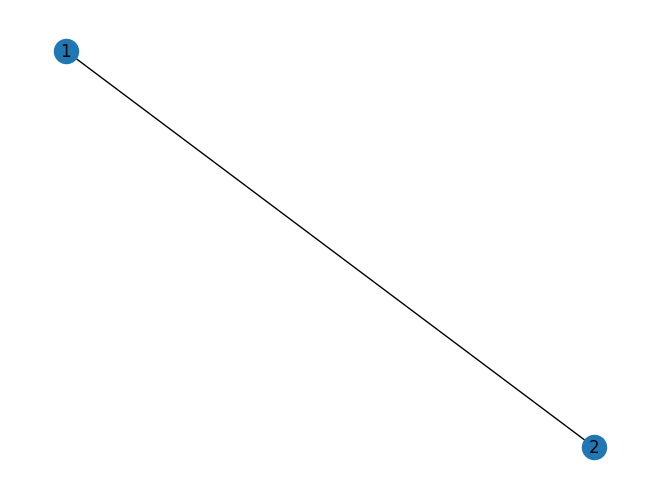

In [61]:
G = nx.Graph([(1, 2, {"color": "yellow"})])
print(G[1])  # same as G.adj[1]
print(G[1][2])
print(G.edges[1, 2])
nx.draw(G, with_labels=True)

You can get/set the attributes of an edge using subscript notation if the edge already exists.

In [62]:
G.add_edge(1, 3)
G[1][3]['color'] = "blue"
G.edges[1, 2]['color'] = "red"
print(G.edges[1, 2])
print(G.edges[1,3])

{'color': 'red'}
{'color': 'blue'}


Fast examination of all (node, adjacency) pairs is achieved using `G.adjacency()`, or `G.adj.items()`. Note that for undirected graphs, adjacency iteration sees each edge twice.

(1, 2, 0.125)
(2, 1, 0.125)
(3, 4, 0.375)
(4, 3, 0.375)


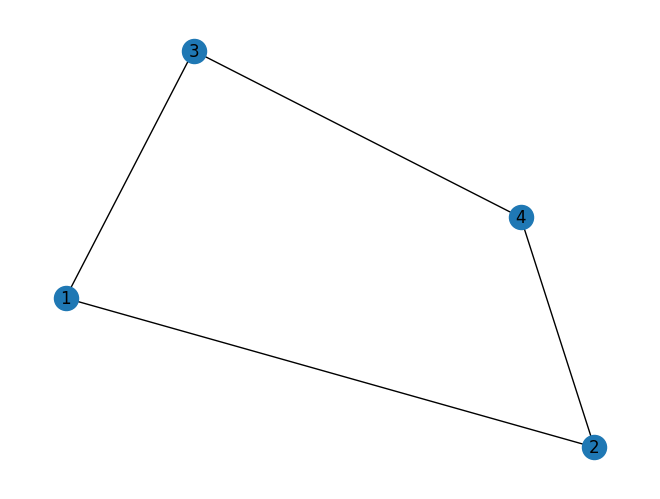

In [64]:
FG = nx.Graph()
FG.add_weighted_edges_from([(1, 2, 0.125), (1, 3, 0.75), (2, 4, 1.2), (3, 4, 0.375)])
for n, nbrs in FG.adj.items():
   for nbr, eattr in nbrs.items():
       wt = eattr['weight']
       if wt < 0.5: print(f"({n}, {nbr}, {wt:.3})")

nx.draw(FG, with_labels=True)

Attributes such as weights, labels, colors, or whatever Python object you like, can be attached to graphs, nodes, or edges.

### Graph Attributes

Assign graph attributes when creating a new graph

In [65]:
G = nx.Graph(day="Friday")
G.graph

{'day': 'Friday'}

Or you can modify attributes later

In [66]:
G.graph['day'] = "Monday"
G.graph

{'day': 'Monday'}